<a href="https://colab.research.google.com/github/Gauravparajuli09/python/blob/deep-learning-practice/Deep_Learning_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd

In [5]:
df = pd.read_csv('/content/drive/MyDrive/Python Practice/Deep Learning With Keras/dataset/train.csv')

/usr/local/lib/python3.7/dist-packages/IPython/core/interactiveshell.py:2882: DtypeWarning: Columns (7) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [6]:
print('shape of the dataset is', df.shape)

shape of the dataset is (1001599, 10)


In [7]:
df.head(5)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Id
0,1,5,2015-07-17,4852,519,1,1,0,0,303445
1,2,5,2015-07-17,4518,495,1,1,0,1,959585
2,3,5,2015-07-17,6679,673,1,1,0,1,739744
3,4,5,2015-07-17,10514,1343,1,1,0,1,864001
4,5,5,2015-07-17,4355,513,1,1,0,1,981931


In [8]:
store = pd.read_csv('/content/drive/MyDrive/Python Practice/Deep Learning With Keras/dataset/store.csv')

In [9]:
store.shape

(1115, 10)

In [10]:
store.head(5)

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [11]:
df_new = df.merge(store, on =['Store'], how = 'inner')
print('new shape is',df_new.shape)

new shape is (1001599, 19)


In [12]:
df_new.head(5)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Id,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-17,4852,519,1,1,0,0,303445,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,1,4,2015-07-16,4427,517,1,1,0,0,324709,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
2,1,3,2015-07-15,4767,550,1,1,0,0,64663,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
3,1,2,2015-07-14,5042,544,1,1,0,0,704685,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
4,1,1,2015-07-13,5054,553,1,1,0,0,308477,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN


In [13]:
df_new.dtypes

Store                          int64
DayOfWeek                      int64
Date                          object
Sales                          int64
Customers                      int64
Open                           int64
Promo                          int64
StateHoliday                  object
SchoolHoliday                  int64
Id                             int64
StoreType                     object
Assortment                    object
CompetitionDistance          float64
CompetitionOpenSinceMonth    float64
CompetitionOpenSinceYear     float64
Promo2                         int64
Promo2SinceWeek              float64
Promo2SinceYear              float64
PromoInterval                 object
dtype: object

In [14]:
df_new['DayOfWeek'].value_counts()

5    143615
4    143615
3    143435
2    143434
1    142500
7    142500
6    142500
Name: DayOfWeek, dtype: int64

In [15]:
import numpy as np

In [16]:
#we can extract all date properties from a datetime datatype import numpy as np
df_new['Date'] = pd.to_datetime(df_new['Date'], infer_datetime_format=True)
df_new['Month']= df_new['Date'].dt.month
df_new['Quarter']=df_new['Date'].dt.quarter
df_new['Year']=df_new['Date'].dt.year
df_new['Day']=df_new['Date'].dt.day
df_new['Week']=df_new['Date'].dt.week

df_new['Season']=np.where(df_new['Month'].isin([3,4,5]),"Spring",
                                 np.where(df_new['Month'].isin([6,7,8]),"Summer",
                                          np.where(df_new['Month'].isin([9,10,11]),"Fall",
                                                   np.where(df_new['Month'].isin([12,1,2]),"Winter","None"))))

#using the head command to view (only) the data and the engineered features
print(df_new[['Date','Year','Month','Day','Week','Quarter','Season']].head())

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:7: FutureWarning: Series.dt.weekofyear and Series.dt.week have been deprecated.  Please use Series.dt.isocalendar().week instead.
  import sys


        Date  Year  Month  Day  Week  Quarter  Season
0 2015-07-17  2015      7   17    29        3  Summer
1 2015-07-16  2015      7   16    29        3  Summer
2 2015-07-15  2015      7   15    29        3  Summer
3 2015-07-14  2015      7   14    29        3  Summer
4 2015-07-13  2015      7   13    29        3  Summer


In [17]:
#import matplotlib for visualizing the data
import matplotlib.pyplot as plt
%matplotlib inline

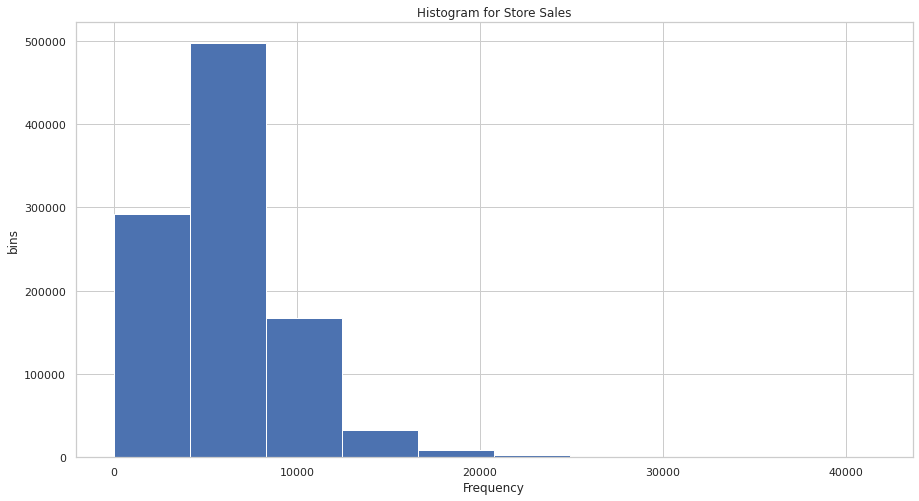

In [18]:
#create a histogram to study daily sales for the stores
plt.figure(figsize=(15,8))
plt.hist(df_new['Sales'])
plt.title("Histogram for Store Sales")
plt.ylabel('bins')
plt.xlabel("Frequency")
plt.show()

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7fe63392f690>,
      dtype=object)

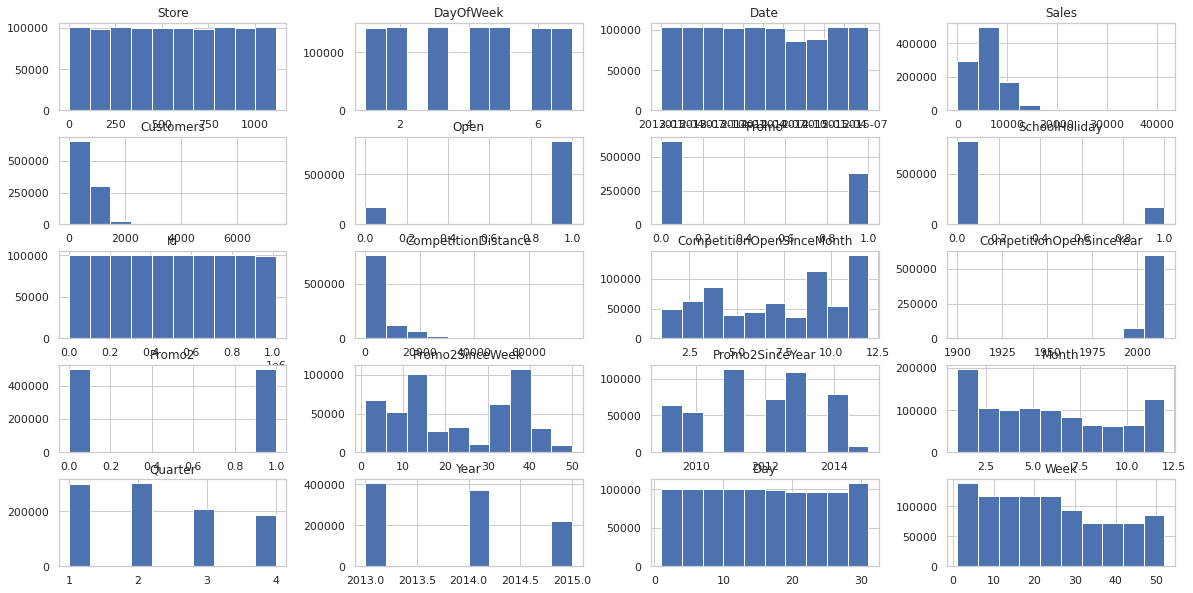

In [19]:
#Use the histogram function provided by the Pandas object
#The function returns a cross-tab histogram plot for all numeric columns in the data
df_new.hist(figsize=(20,10))


In [20]:
#find the null value in the data
df_new.isnull().sum()/df_new.shape[0]*100

Store                         0.000000
DayOfWeek                     0.000000
Date                          0.000000
Sales                         0.000000
Customers                     0.000000
Open                          0.000000
Promo                         0.000000
StateHoliday                  0.000000
SchoolHoliday                 0.000000
Id                            0.000000
StoreType                     0.000000
Assortment                    0.000000
CompetitionDistance           0.259585
CompetitionOpenSinceMonth    31.788370
CompetitionOpenSinceYear     31.788370
Promo2                        0.000000
Promo2SinceWeek              49.961611
Promo2SinceYear              49.961611
PromoInterval                49.961611
Month                         0.000000
Quarter                       0.000000
Year                          0.000000
Day                           0.000000
Week                          0.000000
Season                        0.000000
dtype: float64

In [21]:
#replace nulls with mode
df_new["CompetitionDistance"]=df_new["CompetitionDistance"].fillna(df_new['CompetitionDistance'].mode()[0])

In [22]:
#Double check if we still see nulls for the column
df_new["CompetitionDistance"].isnull().sum()/df_new.shape[0]*100

0.0

In [23]:
import seaborn as sns
#Seaborn is another powerful tool for visualizing the data in python
sns.set(style='whitegrid')

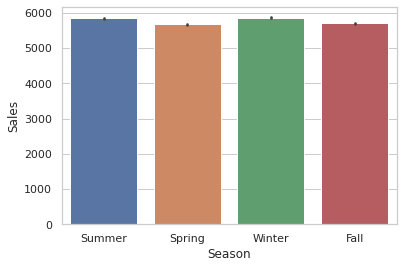

In [24]:
ax = sns.barplot(x= 'Season',y = 'Sales', data = df_new)

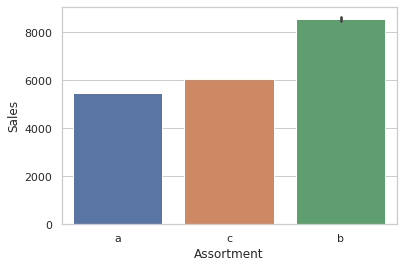

In [25]:
ax = sns.barplot(x = "Assortment", y = 'Sales', data = df_new)

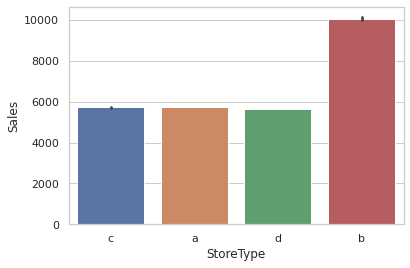

In [26]:
ax = sns.barplot(x='StoreType', y = "Sales", data = df_new)

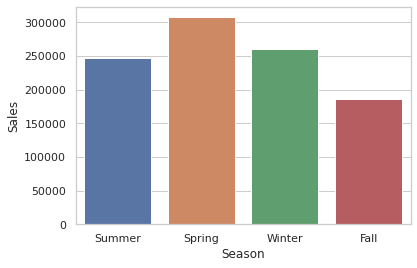

In [27]:
ax = sns.barplot(x= 'Season',y = 'Sales', data = df_new, estimator = np.size)

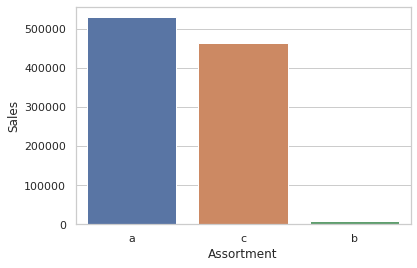

In [28]:
ax = sns.barplot(x = "Assortment", y = 'Sales', data = df_new, estimator = np.size)

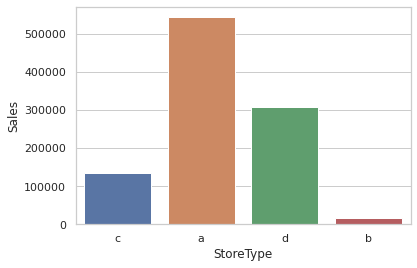

In [29]:
ax = sns.barplot(x = "StoreType", y = 'Sales', data = df_new, estimator = np.size)